In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

## Dataset Upload

This notebook expects the dataset to be uploaded as a **ZIP file**.

Before running the next cell:

1. Download or locate the **`diabetes.zip`** file in the project folder.
2. Run the next cell.
3. When prompted, select **`diabetes.zip`** (not `diabetes.csv`).

The notebook will automatically extract the ZIP archive and load the `diabetes.csv` dataset for preprocessing, model training, and evaluation.

> **Note:** The zip file name can be renamed but a dataset name other than `diabetes.csv` may result in an error.

In [30]:
from google.colab import files
import pandas as pd
import zipfile
import io

uploaded = files.upload()

zip_file_name = list(uploaded.keys())[0]

with zipfile.ZipFile(io.BytesIO(uploaded[zip_file_name]), 'r') as z:
    z.extractall()

df = pd.read_csv("diabetes.csv")

Saving diabetes.zip to diabetes (1).zip


In [31]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [32]:
print("Shape:", df.shape)

df.info()

Shape: (768, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [61]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,121.656250,72.386719,29.108073,140.671875,32.455208,0.471876,33.240885,0.348958
std,3.369578,30.438286,12.096642,8.791221,86.383060,6.875177,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.750000,64.000000,25.000000,121.500000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,29.000000,125.000000,32.300000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


## Data Preprocessing

Although the dataset contains no explicit missing (NaN) values, several medical features contain invalid zero values that are medically impossible eg glucose being 0. These values are treated as missing data and replaced using median imputation.

In [34]:
# its impossible for a column with a value of 0 medically
invalid_zero_columns = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI"
]
# count invalid zero values
print("Invalid zero values before cleaning:")

for column in invalid_zero_columns:
    print(f"{column}: {(df[column] == 0).sum()}")

Invalid zero values before cleaning:
Glucose: 5
BloodPressure: 35
SkinThickness: 227
Insulin: 374
BMI: 11


In [35]:
# Replace 0s with NaN
df[invalid_zero_columns] = df[invalid_zero_columns].replace(0, np.nan)

# Fill missing values using the median
df[invalid_zero_columns] = df[invalid_zero_columns].fillna(
    df[invalid_zero_columns].median()
)

print("Missing values after cleaning:")
print(df.isnull().sum())

Missing values after cleaning:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [36]:
print("Remaining invalid zero values:\n")

for column in invalid_zero_columns:
    print(f"{column}: {(df[column] == 0).sum()}")

Remaining invalid zero values:

Glucose: 0
BloodPressure: 0
SkinThickness: 0
Insulin: 0
BMI: 0


In [62]:
print("Minimum values after preprocessing:")
print(df[invalid_zero_columns].min())

Minimum values after preprocessing:
Glucose          44.0
BloodPressure    24.0
SkinThickness     7.0
Insulin          14.0
BMI              18.2
dtype: float64


In [37]:
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [38]:
df["Outcome"].value_counts()

,count
Outcome,
0,500
1,268


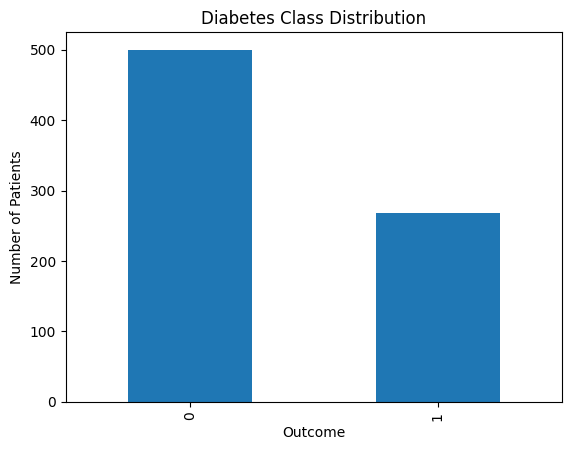

In [39]:
df["Outcome"].value_counts().plot(
    kind="bar",
    title="Diabetes Class Distribution"
)

plt.xlabel("Outcome")
plt.ylabel("Number of Patients")
plt.show()

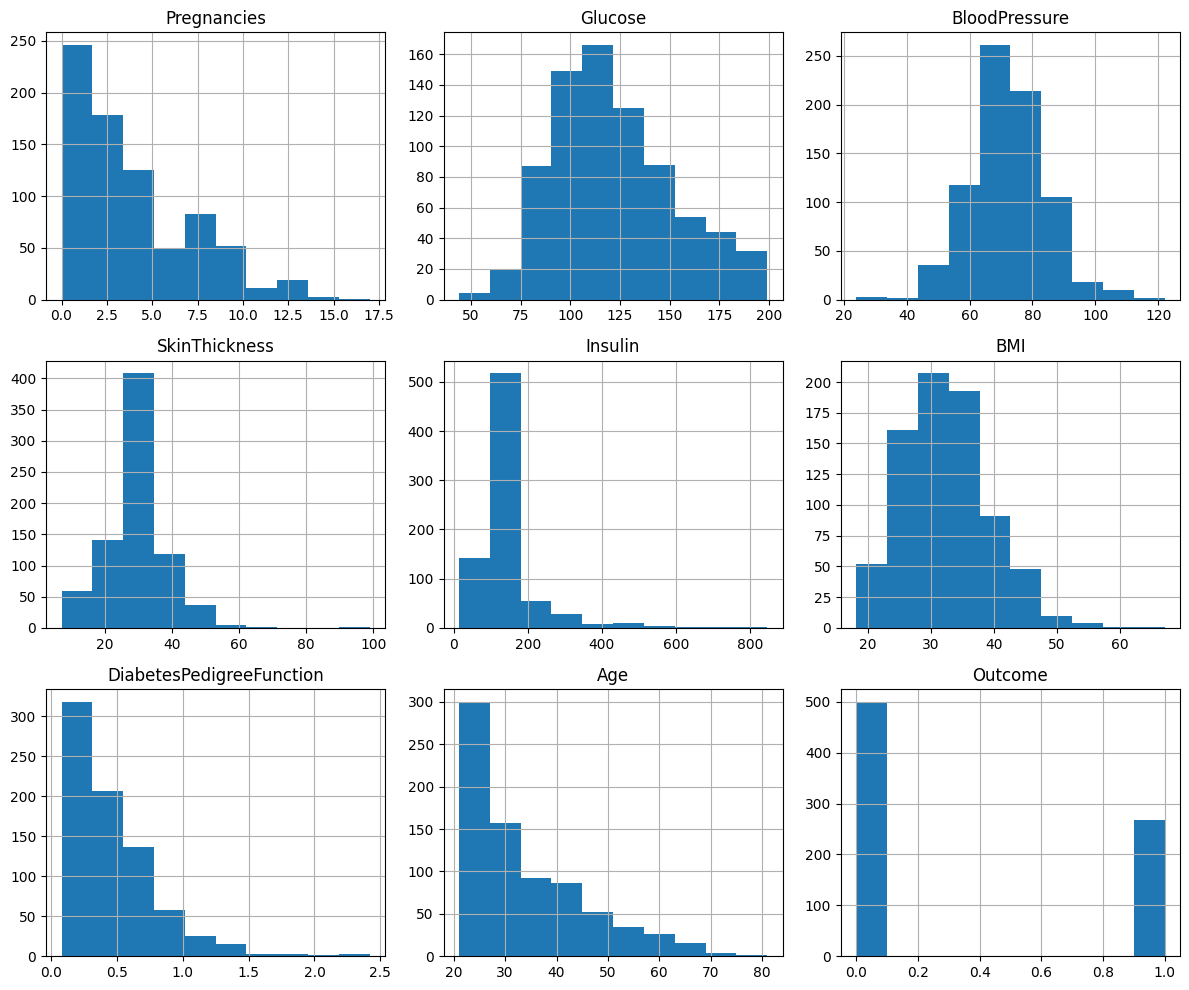

In [40]:
df.hist(figsize=(12,10))

plt.tight_layout()
plt.show()

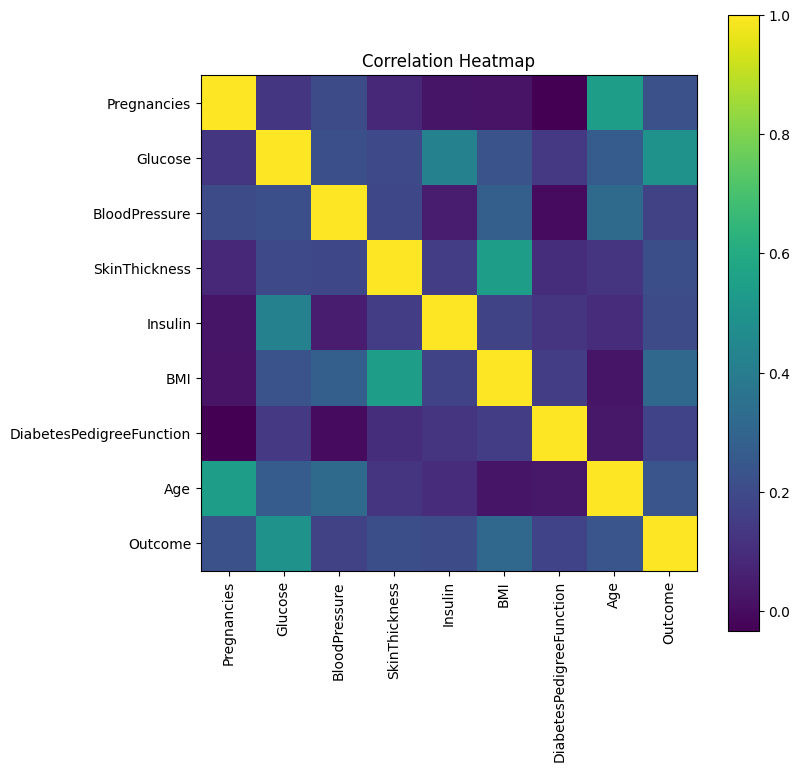

In [41]:
corr = df.corr()

plt.figure(figsize=(8,8))

plt.imshow(corr)

plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)

plt.colorbar()

plt.title("Correlation Heatmap")

plt.show()

In [42]:
# Check for invalid 0 values

print("Remaining invalid zeros:")

for column in invalid_zero_columns:
    print(f"{column}: {(df[column] == 0).sum()}")

Remaining invalid zeros:
Glucose: 0
BloodPressure: 0
SkinThickness: 0
Insulin: 0
BMI: 0


In [43]:
X = df.drop("Outcome", axis=1)

y = df["Outcome"]

In [44]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(614, 8)
(154, 8)


In [45]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [46]:
lr = LogisticRegression()

lr.fit(X_train_scaled, y_train)

lr_predictions = lr.predict(X_test_scaled)

In [47]:
print(classification_report(y_test, lr_predictions))

print("Accuracy:", accuracy_score(y_test, lr_predictions))

print("Precision:", precision_score(y_test, lr_predictions))

print("Recall:", recall_score(y_test, lr_predictions))

print("F1 Score:", f1_score(y_test, lr_predictions))

              precision    recall  f1-score   support

           0       0.80      0.83      0.81        99
           1       0.67      0.62      0.64        55

    accuracy                           0.75       154
   macro avg       0.73      0.72      0.73       154
weighted avg       0.75      0.75      0.75       154

Accuracy: 0.7532467532467533
Precision: 0.6666666666666666
Recall: 0.6181818181818182
F1 Score: 0.6415094339622641


In [48]:
dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train_scaled, y_train)

dt_predictions = dt.predict(X_test_scaled)

In [49]:
print(classification_report(y_test, dt_predictions))

print("Accuracy:", accuracy_score(y_test, dt_predictions))

print("Precision:", precision_score(y_test, dt_predictions))

print("Recall:", recall_score(y_test, dt_predictions))

print("F1 Score:", f1_score(y_test, dt_predictions))

              precision    recall  f1-score   support

           0       0.78      0.77      0.78        99
           1       0.60      0.62      0.61        55

    accuracy                           0.71       154
   macro avg       0.69      0.69      0.69       154
weighted avg       0.72      0.71      0.72       154

Accuracy: 0.7142857142857143
Precision: 0.5964912280701754
Recall: 0.6181818181818182
F1 Score: 0.6071428571428571


In [50]:
rf = RandomForestClassifier(random_state=42)

rf.fit(X_train_scaled, y_train)

rf_predictions = rf.predict(X_test_scaled)

In [51]:
print(classification_report(y_test, rf_predictions))

print("Accuracy:", accuracy_score(y_test, rf_predictions))

print("Precision:", precision_score(y_test, rf_predictions))

print("Recall:", recall_score(y_test, rf_predictions))

print("F1 Score:", f1_score(y_test, rf_predictions))

              precision    recall  f1-score   support

           0       0.80      0.79      0.79        99
           1       0.62      0.64      0.63        55

    accuracy                           0.73       154
   macro avg       0.71      0.71      0.71       154
weighted avg       0.73      0.73      0.73       154

Accuracy: 0.7337662337662337
Precision: 0.625
Recall: 0.6363636363636364
F1 Score: 0.6306306306306306


In [52]:
svm = SVC()

svm.fit(X_train_scaled, y_train)

svm_predictions = svm.predict(X_test_scaled)

In [53]:
print(classification_report(y_test, svm_predictions))

print("Accuracy:", accuracy_score(y_test, svm_predictions))

print("Precision:", precision_score(y_test, svm_predictions))

print("Recall:", recall_score(y_test, svm_predictions))

print("F1 Score:", f1_score(y_test, svm_predictions))

              precision    recall  f1-score   support

           0       0.78      0.84      0.81        99
           1       0.67      0.58      0.62        55

    accuracy                           0.75       154
   macro avg       0.72      0.71      0.72       154
weighted avg       0.74      0.75      0.74       154

Accuracy: 0.7467532467532467
Precision: 0.6666666666666666
Recall: 0.5818181818181818
F1 Score: 0.6213592233009708


In [54]:
results = pd.DataFrame({

    "Model":[
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "SVM"
    ],

    "Accuracy":[
        accuracy_score(y_test, lr_predictions),
        accuracy_score(y_test, dt_predictions),
        accuracy_score(y_test, rf_predictions),
        accuracy_score(y_test, svm_predictions)
    ],

    "Precision":[
        precision_score(y_test, lr_predictions),
        precision_score(y_test, dt_predictions),
        precision_score(y_test, rf_predictions),
        precision_score(y_test, svm_predictions)
    ],

    "Recall":[
        recall_score(y_test, lr_predictions),
        recall_score(y_test, dt_predictions),
        recall_score(y_test, rf_predictions),
        recall_score(y_test, svm_predictions)
    ],

    "F1 Score":[
        f1_score(y_test, lr_predictions),
        f1_score(y_test, dt_predictions),
        f1_score(y_test, rf_predictions),
        f1_score(y_test, svm_predictions)
    ]

})

results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.753247,0.666667,0.618182,0.641509
1,Decision Tree,0.714286,0.596491,0.618182,0.607143
2,Random Forest,0.733766,0.625000,0.636364,0.630631
3,SVM,0.746753,0.666667,0.581818,0.621359


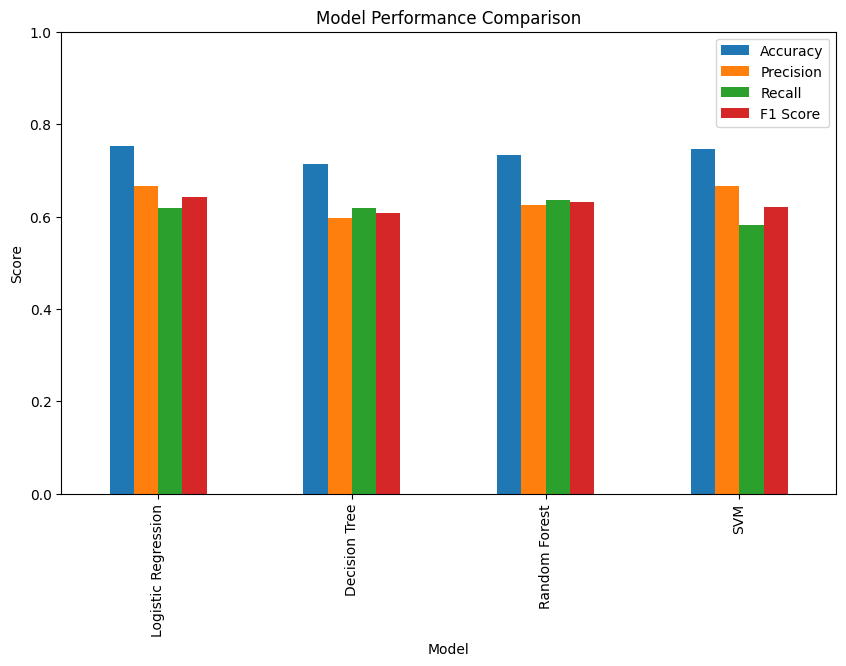

In [55]:
results.set_index("Model").plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Model Performance Comparison")

plt.ylabel("Score")

plt.ylim(0,1)

plt.show()

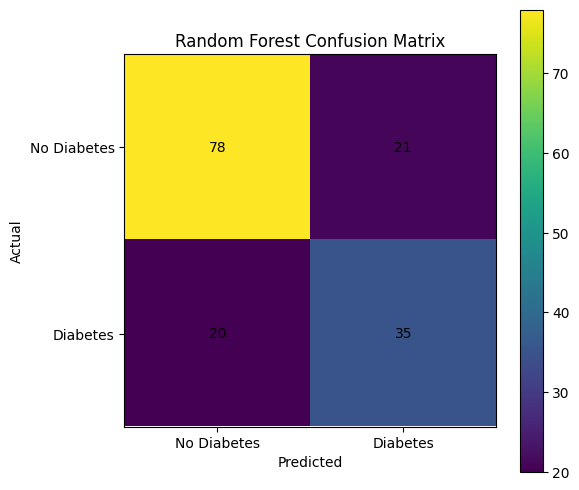

In [56]:
cm = confusion_matrix(y_test, rf_predictions)

plt.figure(figsize=(6,6))

plt.imshow(cm)

plt.title("Random Forest Confusion Matrix")

plt.colorbar()

plt.xticks([0,1],["No Diabetes","Diabetes"])

plt.yticks([0,1],["No Diabetes","Diabetes"])

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i,j], ha="center", va="center")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [57]:
new_patient = [[2, 120, 70, 20, 80, 25.5, 0.35, 35]]

new_patient_scaled = scaler.transform(new_patient)

prediction = rf.predict(new_patient_scaled)

if prediction[0] == 1:
    print("The patient is likely diabetic.")
else:
    print("The patient is likely non-diabetic.")

The patient is likely non-diabetic.


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [58]:
import joblib

# Save the best-performing model
joblib.dump(lr, "diabetes_model.pkl")

# Save the fitted scaler
joblib.dump(scaler, "scaler.pkl")

print("Model saved successfully!")
print("StandardScaler saved successfully!")

Model saved successfully!
StandardScaler saved successfully!


In [59]:
import os

print(os.listdir())

['.config', 'diabetes.zip', 'diabetes.csv', 'diabetes (1).zip', 'diabetes_model.pkl', 'scaler.pkl', 'sample_data']


In [60]:
from google.colab import files

files.download("diabetes_model.pkl")
files.download("scaler.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Model Export

The best-performing model and the fitted StandardScaler are saved using Joblib for deployment in the Streamlit dashboard.